In [1]:
import sys
import os
from pathlib import Path

# 1. Get the current directory of the notebook
# 2. Go up one level to the project root (bistable_model_simulation)
root_dir = Path(os.getcwd()).parent

# 3. Add that root to Python's search path
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

### the example of how the simulations for the well-mixed cases work
##### ------------ TO DO ------------

In [2]:
from scripts.runners.run_well_mixed import run_save_well_mixed_full

Loading data from: well_mixed_data/full_model_7.5_1500.0_tf_500.0_tau5e-7
Data directory set to: /Users/minglu/Documents/Uni/bistable_model_simulation/simulation_data/well_mixed_data/full_model_7.5_1500.0_tf_500.0_tau5e-7
 Loaded 1 runs. Combined 10000000 points.
Loading data from: well_mixed_data/full_model_1.5_1500.0_tf_500.0_tau5e-7
Data directory set to: /Users/minglu/Documents/Uni/bistable_model_simulation/simulation_data/well_mixed_data/full_model_1.5_1500.0_tf_500.0_tau5e-7
 Loaded 1 runs. Combined 10000000 points.
Loading data from: well_mixed_data/full_model_0.3_1500.0_tf_500.0_tau5e-7
Data directory set to: /Users/minglu/Documents/Uni/bistable_model_simulation/simulation_data/well_mixed_data/full_model_0.3_1500.0_tf_500.0_tau5e-7
 Loaded 1 runs. Combined 10000000 points.
Loading data from: well_mixed_data/full_model_1.5_7500.0_tf_500.0_tau5e-7
Data directory set to: /Users/minglu/Documents/Uni/bistable_model_simulation/simulation_data/well_mixed_data/full_model_1.5_7500.0_tf_

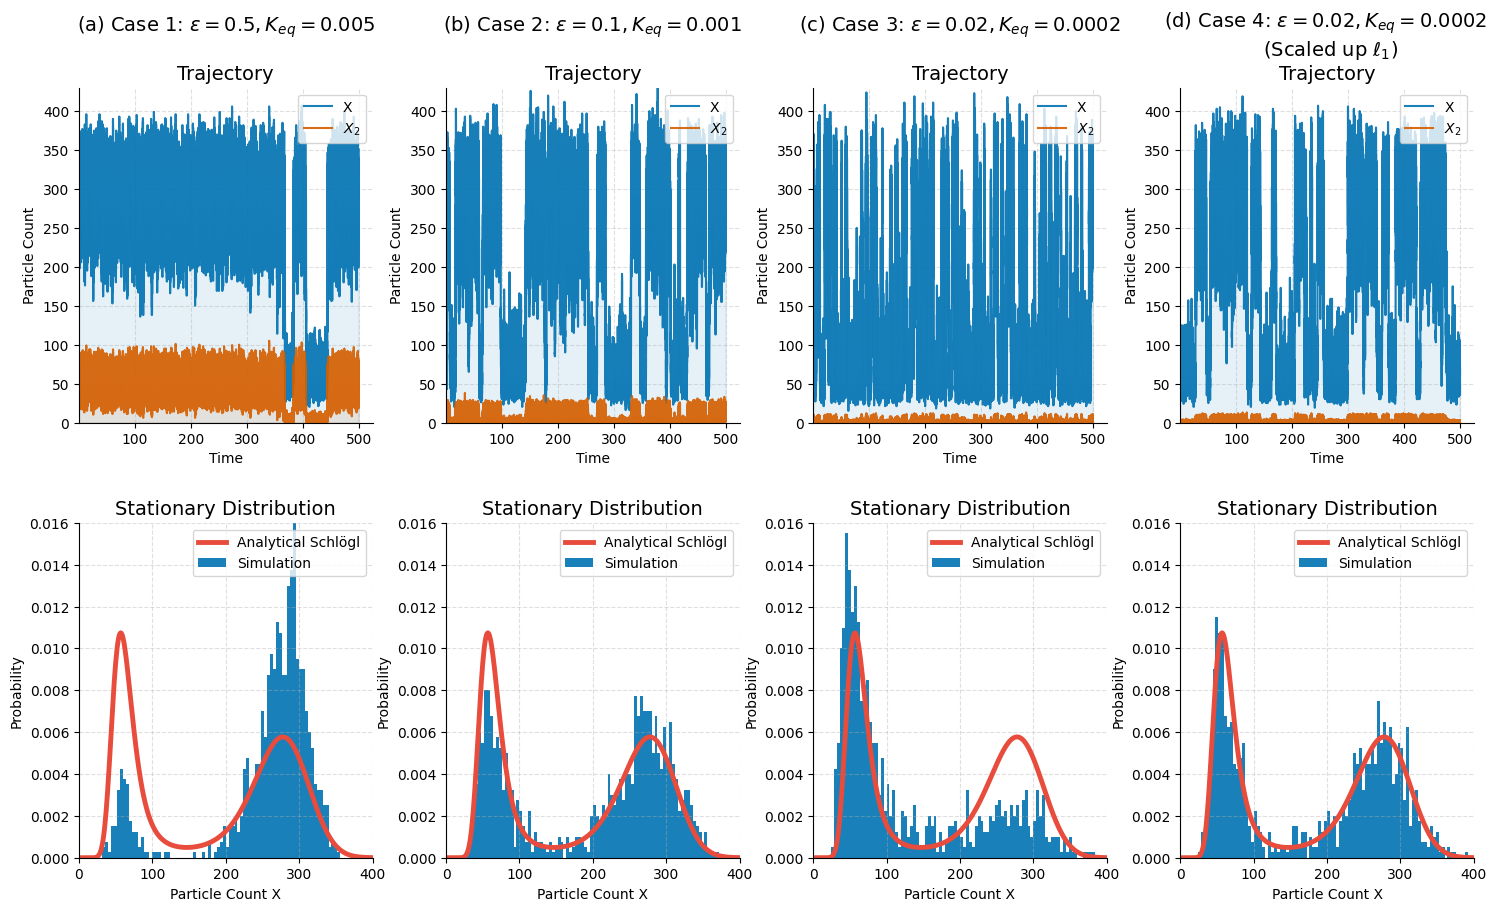

In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Connect to your project modules
# (assuming your notebook is inside the 'notebooks/' directory)
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from scripts.analysis.data_loader import load_well_mixed_data
from scripts.analysis.analyze_distributions import hist_np, kde_sk, get_pretty_upper_bound
from simulation.models.analytical_curve import get_analytical_curve
from simulation.solvers.rate_conversions import calculate_k_from_l

# 2. DEFINE YOUR THREE FOLDERS HERE
# (These should be the names of the folders inside 'simulation_data/well_mixed_data/')
folders = [
    "full_model_7.5_1500.0_tf_500.0_tau5e-7",  # e.g., "full_model_..._tau5e-7"
    "full_model_1.5_1500.0_tf_500.0_tau5e-7",  
    "full_model_0.3_1500.0_tf_500.0_tau5e-7",
    "full_model_1.5_7500.0_tf_500.0_tau5e-7"   
]

# Labels that will appear as titles for each column
labels = [
    "(a) Case 1: $\epsilon=0.5, K_{eq}=0.005$\n",
    "(b) Case 2: $\epsilon=0.1, K_{eq}=0.001$\n",
    "(c) Case 3: $\epsilon=0.02, K_{eq}=0.0002$\n", # (Scaled up $l_1^\pm$)
    "(d) Case 4: $\epsilon=0.02, K_{eq}=0.0002$ \n (Scaled up $\ell_1$)"
]

# 3. SETUP THE FIGURE
# 2 rows (Trajectory, Distribution) x 4 columns (Cases)
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(18, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

color_x = "#0072B2"
color_x2 = "#D55E00"

for col, (folder, label) in enumerate(zip(folders, labels)):
    file_str = "well_mixed_data/" + folder
    print(f"Loading data from: {file_str}")
    
    # Load data
    trajectories, combined_data, metadata = load_well_mixed_data(file_str=file_str)
    
    if not trajectories:
        print(f"  -> Skipping {folder} - no data found.")
        continue

    tau = metadata['timestep']
    # Downsample data slightly to speed up plotting/density calculations
    slice_val = max(1, int(5e-3 / tau))

    # ==========================================
    # --- TOP ROW: Trajectory ---
    # ==========================================
    ax_traj = axs[0, col]
    traj = trajectories[0] # Just plot the first trajectory as an example
    x_time = traj['timescale']
    y_x = traj['species_log']['X']
    
    ax_traj.plot(x_time, y_x, color=color_x, label='X', drawstyle='steps-post', alpha=0.9, linewidth=1.5)
    ax_traj.fill_between(x_time, y_x, color=color_x, step='post', alpha=0.1)
    
    # If full model, plot X2 as well
    if 'X2' in traj['species_log']:
        y_x2 = traj['species_log']['X2']
        ax_traj.plot(x_time, y_x2, color=color_x2, label='$X_2$', drawstyle='steps-post', alpha=0.9, linewidth=1.5)
        ax_traj.fill_between(x_time, y_x2, color=color_x2, step='post', alpha=0.1)
        
    ax_traj.set_title(f"{label}\nTrajectory", fontsize=14)
    ax_traj.set_xlabel('Time')
    ax_traj.set_ylabel('Particle Count')
    ax_traj.legend(loc='upper right')
    ax_traj.grid(True, linestyle='--', alpha=0.4)
    ax_traj.spines['top'].set_visible(False)
    ax_traj.spines['right'].set_visible(False)
    ax_traj.set_xlim(left=x_time[0])
    ax_traj.set_ylim(0, 430)

    # ==========================================
    # --- BOTTOM ROW: Distribution ---
    # ==========================================
    ax_dist = axs[1, col]
    combined_data_X = combined_data['X'][::slice_val]
    upper_bound = get_pretty_upper_bound(combined_data_X)
    
    bin_width = 4.0
    band_width = 2.5714 # Project default bandwidth
    
    hist_bin, density_hist = hist_np(combined_data_X, upper_bound, bin_width)
    # x_axis_plot, kde_X = kde_sk(combined_data_X, upper_bound, band_width)
    
    # Analytical Curve calculation
    macrorates = metadata['macrorates']
    a = metadata['a']
    b = metadata['b']
    vol = metadata['vol']
    
    # If full model, convert macroscopic l to k to get the Schlögl analytical curve
    if len(combined_data) > 1:
        macrorates_k = calculate_k_from_l(macrorates)
    else:
        macrorates_k = macrorates
        
    p_states, stat_dist = get_analytical_curve(upper_bound, macrorates_k, a, b, vol)

    ax_dist.bar(hist_bin, density_hist, width=bin_width, color= "#0072B2", alpha=0.9, label='Simulation') # , edgecolor='white'
    # ax_dist.plot(x_axis_plot, kde_X, color='#1f77b4', linewidth=2.5, label='KDE')
    ax_dist.plot(p_states, stat_dist, color='#e74c3c', linewidth=3.5, label='Analytical Schlögl')

    ax_dist.set_title("Stationary Distribution", fontsize=14)
    ax_dist.set_xlabel('Particle Count X')
    ax_dist.set_ylabel('Probability')
    ax_dist.set_xlim(0, upper_bound)
    ax_dist.set_ylim(0, 0.016)
    ax_dist.legend(loc='upper right')
    ax_dist.grid(True, linestyle='--', alpha=0.4)
    ax_dist.spines['top'].set_visible(False)
    ax_dist.spines['right'].set_visible(False)

# Add a super title for the whole figure
# fig.suptitle("Enforcing Time-Scale Separation in the Full Reaction Network", fontsize=18, y=0.98, fontweight='bold')

# Save the figure as a high-res image suitable for a thesis
plt.savefig("time_scale_separation.pdf", dpi=300, bbox_inches='tight')
plt.show()